# Assignment 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
directory = "./a_3/"

## Task 1: Effect of low and high frequencies on image reconstruction error 

## a.

In [2]:
def dft1d(input):
    N = len(input)
    x = np.arange(N)
    u = x.reshape((-1, 1))
    # As u is of shape(N, 1) and x is of shape(N, ), u*x performs a matrix multiplication of (N,1) x (1,N) resulting
    # in an (NxN) matrix, where in a row, x would be iterated and in a column, u would be iterated
    result_matrix = np.exp(-2j*(np.pi*u*x)/N)
    return result_matrix @ input

def dft2d(input):
    # Perform row wise 1D dft
    intermediate = np.array([dft1d(row) for row in input])
    # Perform column wise 1D dft
    result = np.array([dft1d(col) for col in intermediate.T]).T
    return result

def shift2d(input):
  output = np.zeros_like(input)

  output[:(output.shape[0] // 2), :(output.shape[1] // 2)] = input[(input.shape[0] // 2):, (input.shape[1] // 2):]
  output[:(output.shape[0] // 2), (output.shape[1] // 2):] = input[(input.shape[0] // 2):, :(input.shape[1] // 2)]
  output[(output.shape[0] // 2):, :(output.shape[1] // 2)] = input[:(input.shape[0] // 2), (input.shape[1] // 2):]
  output[(output.shape[0] // 2):, (output.shape[1] // 2):] = input[:(input.shape[0] // 2), :(input.shape[1] // 2)]
  return output

In [3]:
a_3_1 = cv2.imread(directory+"a_3_1.png")
a_3_1 = cv2.cvtColor(a_3_1, cv2.COLOR_BGR2GRAY)

a_3_1_fourier = dft2d(a_3_1)
a_3_1_fourier_sift = shift2d(a_3_1_fourier)

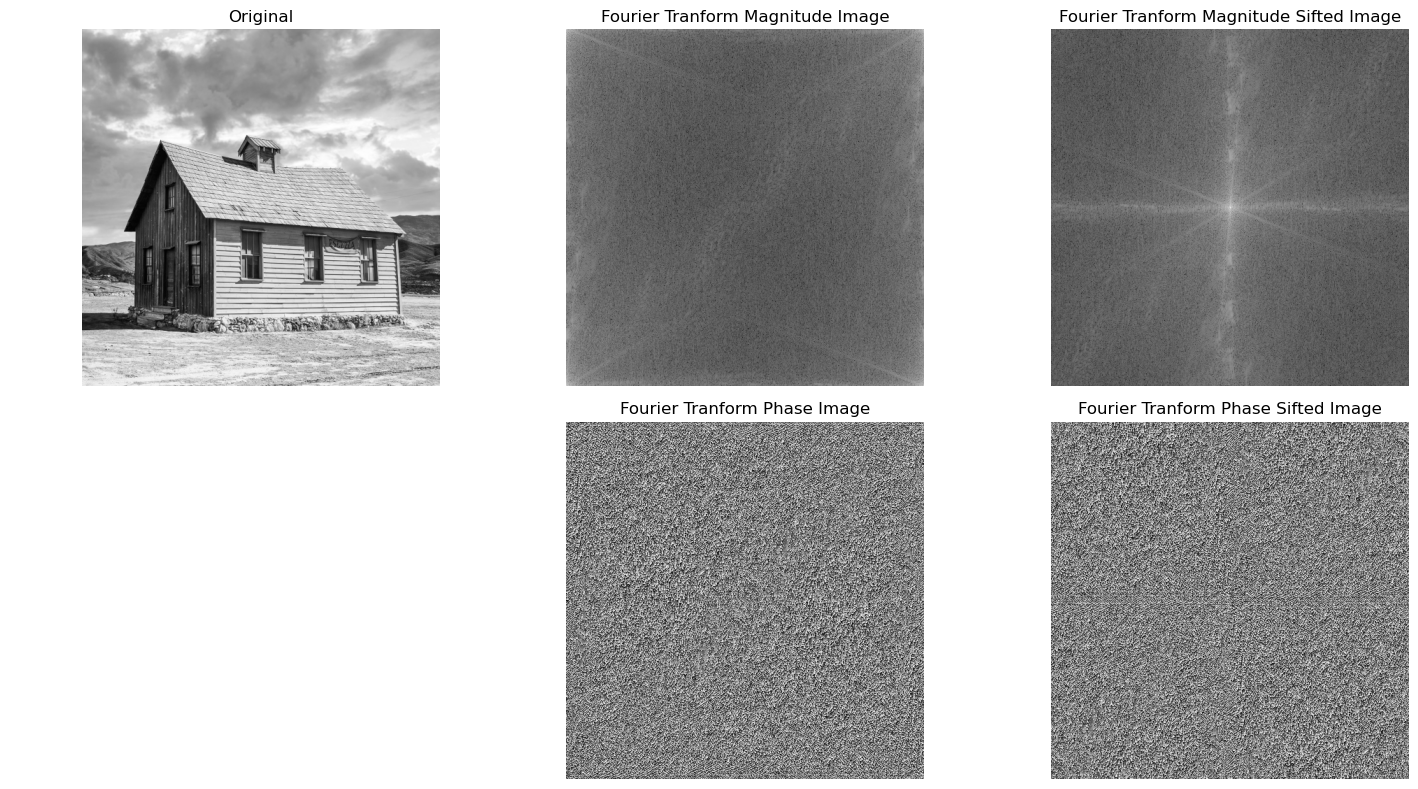

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].imshow(a_3_1, cmap='gray')
axes[0, 0].set_title("Original")
axes[0, 0].axis('off')
axes[0, 1].imshow(np.log(np.abs(a_3_1_fourier)), cmap="gray")
axes[0, 1].set_title("Fourier Tranform Magnitude Image")
axes[0, 1].axis('off')
axes[0, 2].imshow(np.log(np.abs(a_3_1_fourier_sift)), cmap="gray")
axes[0, 2].set_title("Fourier Tranform Magnitude Sifted Image")
axes[0, 2].axis('off')
axes[1, 0].axis('off')
axes[1, 1].imshow(np.angle(a_3_1_fourier), cmap="gray")
axes[1, 1].set_title("Fourier Tranform Phase Image")
axes[1, 1].axis('off')
axes[1, 2].imshow(np.angle(a_3_1_fourier_sift), cmap="gray")
axes[1, 2].set_title("Fourier Tranform Phase Sifted Image")
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

## b.

In [5]:
def idft1d(input):
    N = len(input)
    u = np.arange(N)
    x = u.reshape((-1, 1))
    # As u is of shape(N, 1) and x is of shape(N, ), u*x performs a matrix multiplication of (N,1) x (1,N) resulting
    # in an (NxN) matrix, where in a row, x would be iterated and in a column, u would be iterated
    result_matrix = np.exp(2j*(np.pi*x*u)/N)
    return (1/N)*result_matrix @ input

def idft2d(input):
    # Perform row wise 1D idft
    intermediate = np.array([idft1d(row) for row in input])
    # Perform column wise 1D idft
    result = np.array([idft1d(col) for col in intermediate.T]).T
    return result

In [45]:
def lowPassFilter(fourier_img, Do):
    M = fourier_img.shape[1]
    N = fourier_img.shape[0]
    x = np.arange(M).reshape((1, -1))
    y = np.arange(N).reshape((-1, 1))
    # Distance of each pixel from the center pixel
    dist = (x - x.max()//2)**2 + (y - y.max()//2)**2
    # A mask where if distance > Do^2, then it is true, else false
    mask = (dist > Do**2)
    filtered_img = a_3_1_fourier.copy()
    filtered_img = shift2d(filtered_img)
    filtered_img[mask] = 0
    filtered_img = shift2d(filtered_img)
    return filtered_img

In [46]:
a_3_1_fourier_filtered = lowPassFilter(a_3_1_fourier, 200)
a_3_1_idft = idft2d(a_3_1_fourier_filtered)

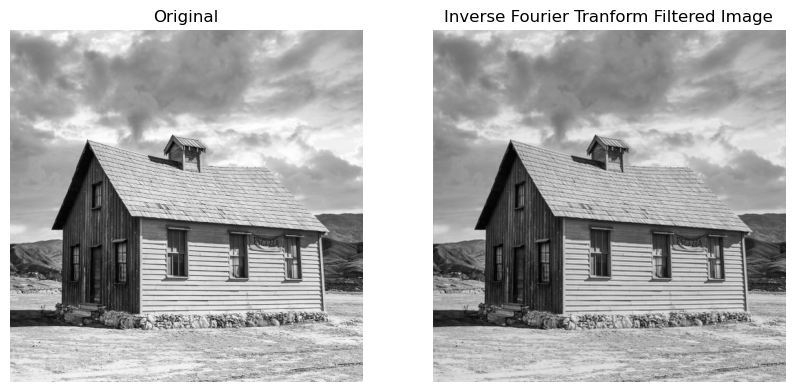

In [48]:
plt.figure(figsize=(10, 20))
plt.subplot(1, 2, 1).imshow(a_3_1, cmap='gray')
plt.subplot(1, 2, 1).axis('off')
plt.title("Original")
plt.subplot(1, 2, 2).imshow(np.abs(a_3_1_idft), cmap='gray')
plt.subplot(1, 2, 2).axis('off')
plt.title("Inverse Fourier Tranform Filtered Image")
plt.show()

## c.

In [49]:
reconstruction_errors = []
Dos = [10, 50, 100, 200, 300, 400, 500, 1000]
a_3_1_idfts = []

# Array of various idfts at low pass filtered at various values of Do
a_3_1_idfts = [idft2d(lowPassFilter(a_3_1_fourier, d)) for d in Dos]

# Calculate MSE for each reconstructed image
for transform in a_3_1_idfts:
    error = (1/transform.shape[0])*(1/transform.shape[1])*(np.sum((a_3_1 - np.abs(transform))**2))
    reconstruction_errors.append(error)

## d.

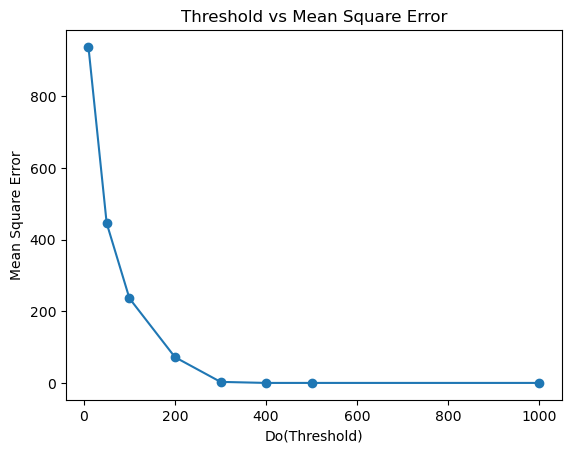

In [50]:
plt.plot(Dos, reconstruction_errors, marker='o')
plt.xlabel("Do(Threshold)")
plt.ylabel("Mean Square Error")
plt.title("Threshold vs Mean Square Error")
plt.show()

In [11]:
print(reconstruction_errors[5])
print(reconstruction_errors[6])

2.4613170708191266e-22
2.4613170708191266e-22


### We see observe that the Mean Squared Error decreases for increasing values of threshold, this is because for increasing values of threshold, we are allowing more frequecies for the reconstruction of the image, allowing for a more accurate reconstruction. We can also see that for Do = 400 and Do = 500, the errors are the same, thus indicating that there aren't any major contributions of frequency past the threshold Do = 400. Also the error is not zero but very close to zero due to small floating point calculation precision limits

## Task 2: Creating a hybrid image in the frequency domain

## a.

In [12]:
def applyLowGaussianFilter(fourier_img, sigma):
    M = fourier_img.shape[1]
    N = fourier_img.shape[0]
    x = np.arange(-M//2, M//2)
    x = x.reshape((1, -1))
    y = np.arange(-N//2, N//2)
    y = y.reshape((-1, 1))

    # Low pass gaussian filter
    gaussian = np.exp((x**2 + y**2)/(-2*(sigma**2)))
    img = fourier_img.copy() 
    img = img*gaussian
    return img

def applyHighGaussianFilter(fourier_img, sigma):
    M = fourier_img.shape[1]
    N = fourier_img.shape[0]
    x = np.arange(-M//2, M//2)
    x = x.reshape((1, -1))
    y = np.arange(-N//2, N//2)
    y = y.reshape((-1, 1))

    # High pass gaussian filter
    gaussian = 1-np.exp((x**2 + y**2)/(-2*(sigma**2)))
    img = fourier_img.copy() 
    img = img*gaussian
    return img

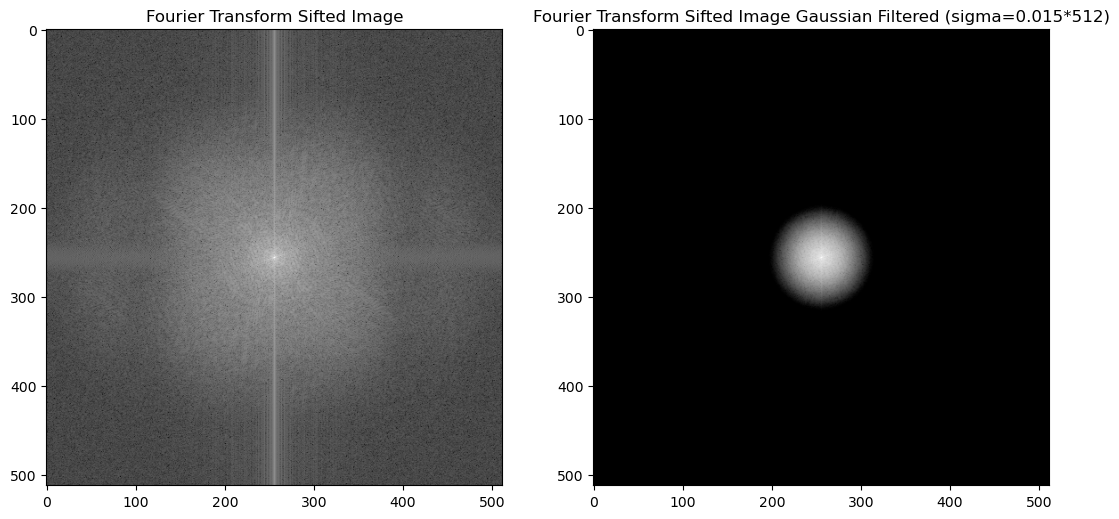

In [13]:
a_3_2_1 = cv2.imread(directory+"a_3_2_1.png")
a_3_2_1 = cv2.cvtColor(a_3_2_1, cv2.COLOR_BGR2GRAY)

a_3_2_1_fourier = dft2d(a_3_2_1)
a_3_2_1_fourier_sift = shift2d(a_3_2_1_fourier)

plt.figure(figsize=(20, 30))
eps = 1e-8
plt.subplot(1, 3, 1).imshow(np.log(np.abs(a_3_2_1_fourier_sift)), cmap = 'gray')
plt.title("Fourier Transform Sifted Image")
plt.subplot(1, 3, 2).imshow(np.log(np.abs(applyLowGaussianFilter(a_3_2_1_fourier_sift, 0.015*a_3_2_1_fourier_sift.shape[0])) + eps), cmap = 'gray')
plt.title("Fourier Transform Sifted Image Gaussian Filtered (sigma=0.015*512)")
plt.show()

In [14]:
a_3_2_1_filtered = applyLowGaussianFilter(a_3_2_1_fourier_sift, 0.015*a_3_2_1_fourier_sift.shape[0])
a_3_2_1_filtered_idft = idft2d(shift2d(a_3_2_1_filtered))

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

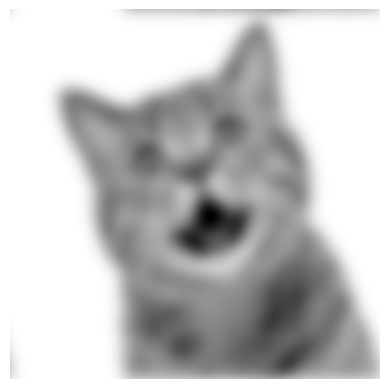

In [15]:
plt.subplot(1, 1, 1).imshow(np.abs(a_3_2_1_filtered_idft), cmap='gray')
plt.axis('off')

## b.

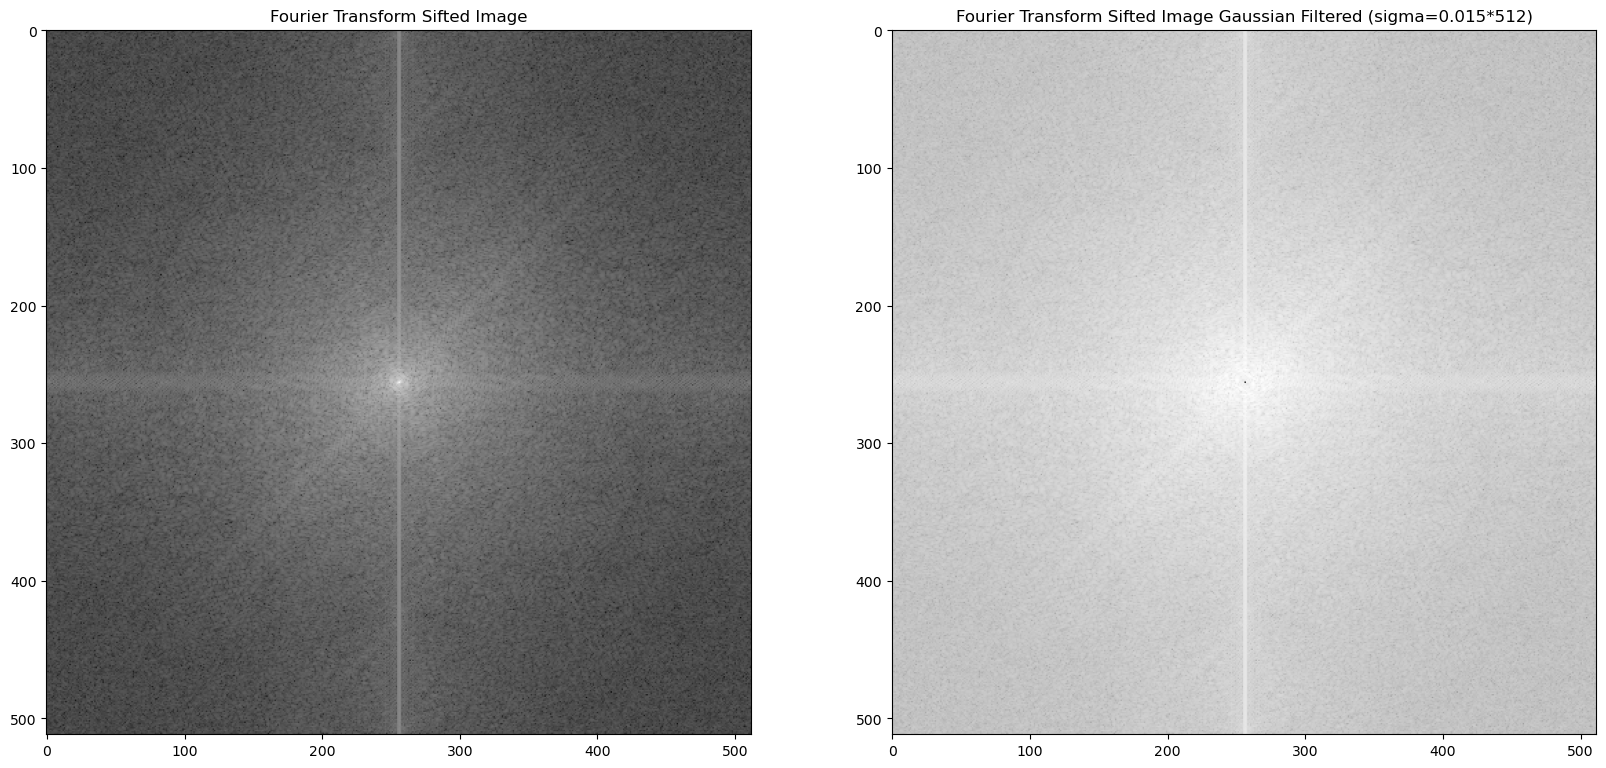

In [16]:
a_3_2_2 = cv2.imread(directory+"a_3_2_2.png")
a_3_2_2 = cv2.cvtColor(a_3_2_2, cv2.COLOR_BGR2GRAY)

a_3_2_2_fourier = dft2d(a_3_2_2)
a_3_2_2_fourier_sift = shift2d(a_3_2_2_fourier)

plt.figure(figsize=(20, 30))
eps = 1e-8
plt.subplot(1, 2, 1).imshow(np.log(np.abs(a_3_2_2_fourier_sift)), cmap = 'gray')
plt.title("Fourier Transform Sifted Image")
plt.subplot(1, 2, 2).imshow(np.log(np.abs(applyHighGaussianFilter(a_3_2_2_fourier_sift, 0.015*a_3_2_2_fourier_sift.shape[0])) + eps), cmap = 'gray')
plt.title("Fourier Transform Sifted Image Gaussian Filtered (sigma=0.015*512)")
plt.show()

In [17]:
a_3_2_2_filtered = applyHighGaussianFilter(a_3_2_2_fourier_sift, 0.015*a_3_2_2_fourier_sift.shape[0])
a_3_2_2_filtered_idft = idft2d(shift2d(a_3_2_2_filtered))

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

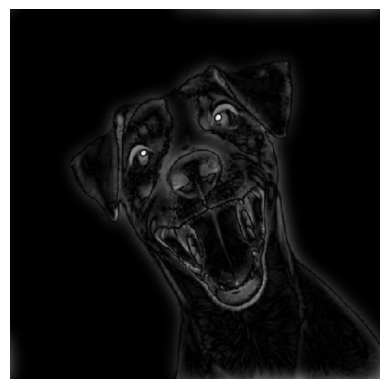

In [18]:
plt.subplot(1, 1, 1).imshow(np.abs(a_3_2_2_filtered_idft), cmap='gray')
plt.axis('off')

## c.

In [19]:
hybrid_spectrum = a_3_2_1_filtered + a_3_2_2_filtered

## d.

In [20]:
hybrid_spectrum_img = idft2d(shift2d(hybrid_spectrum))

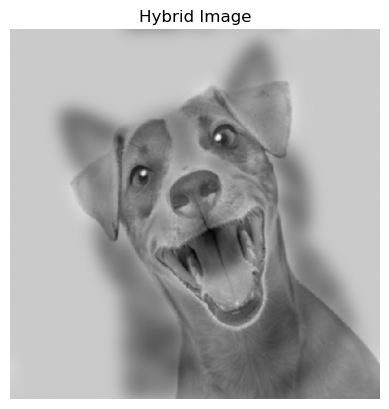

In [21]:
plt.subplot(1, 1, 1).imshow(np.abs(hybrid_spectrum_img), cmap='gray')
plt.subplot(1, 1, 1).axis('off')
plt.title("Hybrid Image")
plt.show()

## e.

### The image from close looks like a dog as it is constructed from high frequency, but as you go farther and farther, the high frequency gets harder detect and as such, we observe the cat from farther behind as the low frequencies are easier to observe from that distance

## Task 3: Watermarking in the frequency domain

## a.

In [22]:
a_3_1 = cv2.imread(directory+"a_3_1.png")
a_3_1 = cv2.cvtColor(a_3_1, cv2.COLOR_BGR2GRAY)

In [23]:
a_3_1_fourier = dft2d(a_3_1)
a_3_1_fourier_sift = shift2d(a_3_1_fourier)

Text(0.5, 1.0, 'Sifted Phase Image')

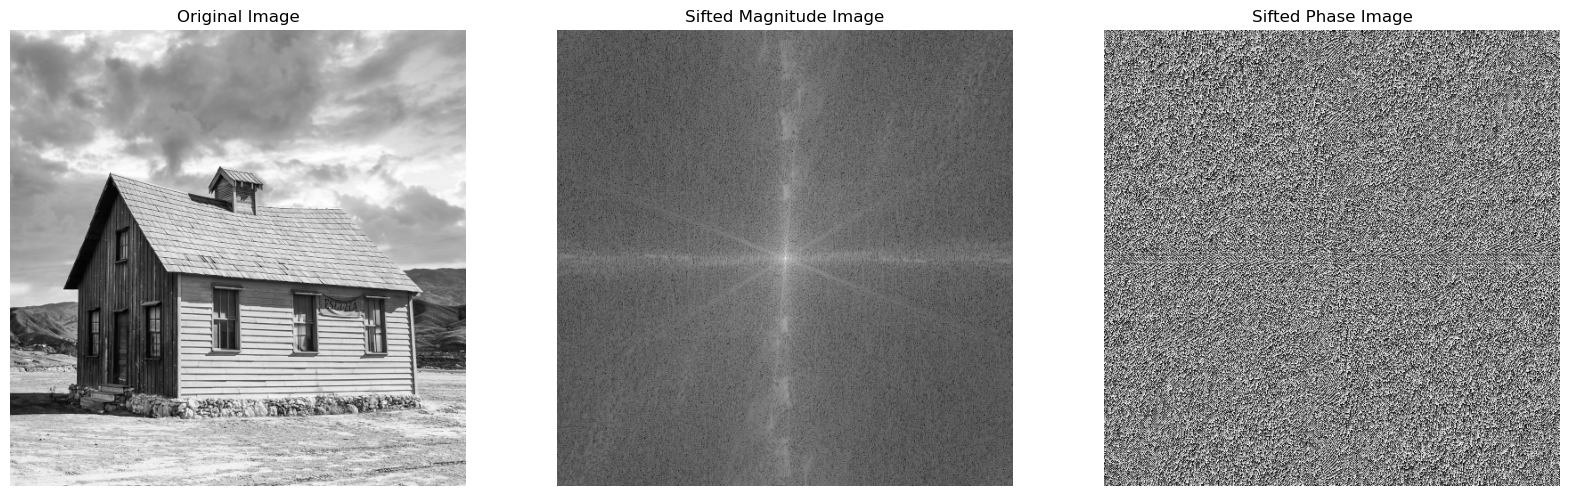

In [24]:
plt.figure(figsize=(20, 30))
plt.subplot(1, 3, 1).imshow(a_3_1, cmap='gray')
plt.subplot(1, 3, 1).axis('off')
plt.title("Original Image")
plt.subplot(1, 3, 2).imshow(np.log(np.abs(a_3_1_fourier_sift)), cmap='gray')
plt.subplot(1, 3, 2).axis('off')
plt.title("Sifted Magnitude Image")
plt.subplot(1, 3, 3).imshow(np.angle(a_3_1_fourier_sift), cmap='gray')
plt.subplot(1, 3, 3).axis('off')
plt.title("Sifted Phase Image")

## b.

In [25]:
a_3_watermark = cv2.imread(directory+"a_3_watermark.png")
a_3_watermark = cv2.cvtColor(a_3_watermark, cv2.COLOR_BGR2GRAY)

# Scaling the pixel values to range [0, 50]
a_3_watermark_scaled = ((a_3_watermark - a_3_watermark.min())/(a_3_watermark.max() - a_3_watermark.min()))*50

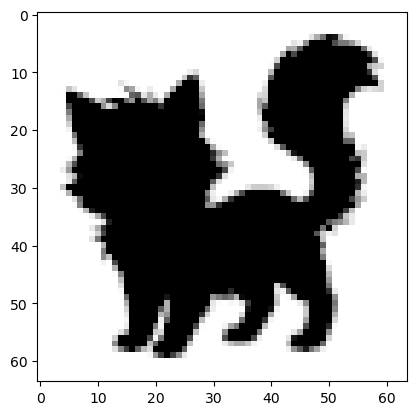

In [26]:
plt.subplot(1, 1, 1).imshow(a_3_watermark_scaled, cmap="gray")

In [27]:
dx, dy = 100, 100
wm_width, wm_height = a_3_watermark.shape[1], a_3_watermark.shape[0]
cx, cy = a_3_1_fourier.shape[1]//2, a_3_1_fourier.shape[0]//2

a_3_1_embedded_fourier_sift = a_3_1_fourier_sift.copy()
magnitude = np.abs(a_3_1_embedded_fourier_sift)
phase = np.angle(a_3_1_embedded_fourier_sift)

# Embed the watermark with offsets (dx, dy) and (-dx, dy) from the center of the image
magnitude[cy+dy-wm_height//2:cy+dy+wm_height//2, cx+dx-wm_width//2:cx+dx+wm_width//2] = a_3_watermark_scaled
magnitude[cy-dy-wm_height//2:cy-dy+wm_height//2, cx-dx-wm_width//2:cx-dx+wm_width//2] = a_3_watermark_scaled

# Rebuild the complete fourier transform
a_3_1_embedded_fourier_sift = magnitude*np.exp(1j*phase)

## c. 

Text(0.5, 1.0, 'Original Sifted Magnitude Plot')

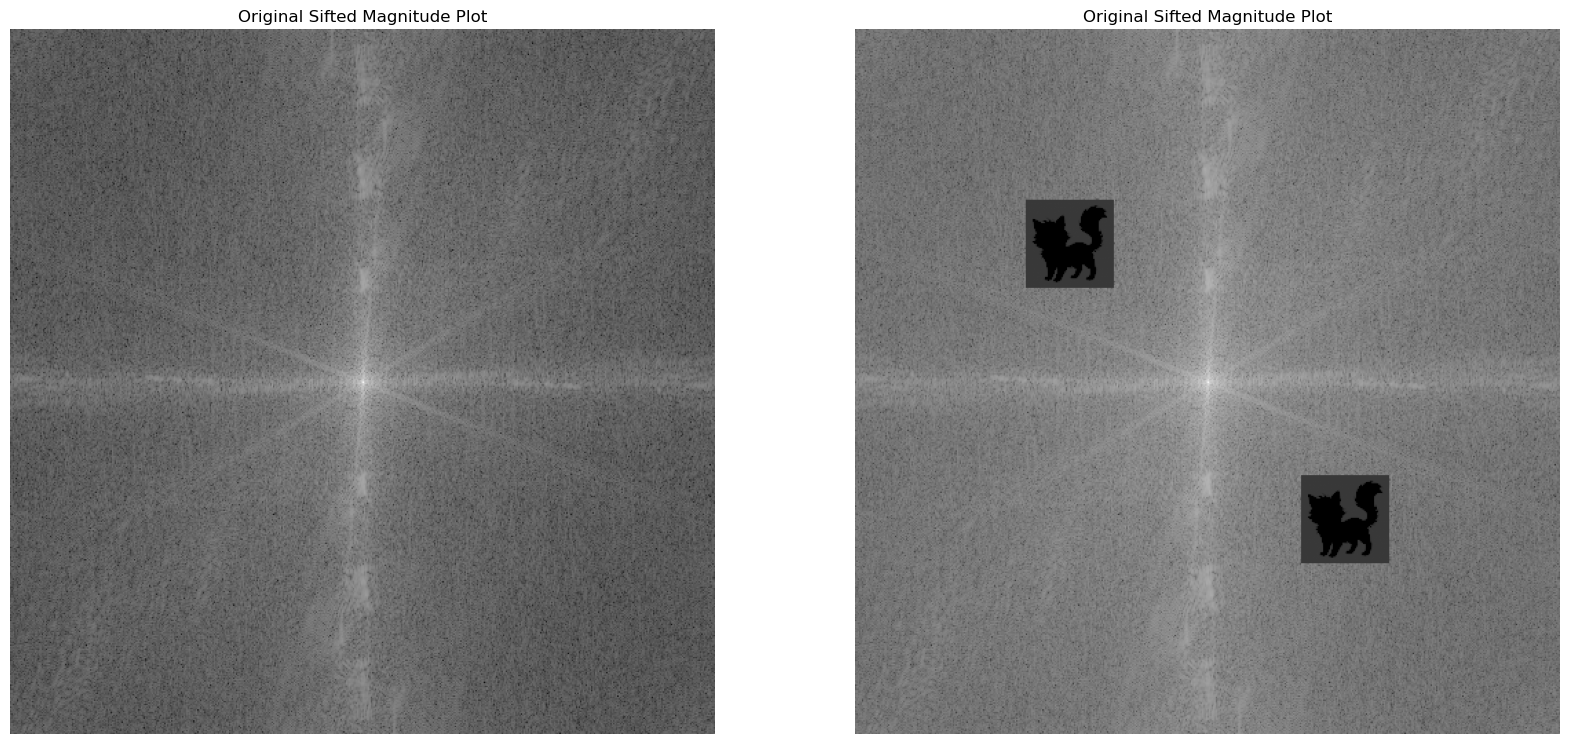

In [28]:
plt.figure(figsize=(20, 30))
plt.subplot(1, 2, 1).imshow(np.log(np.abs(a_3_1_fourier_sift)), cmap='gray')
plt.subplot(1, 2, 1).axis('off')
plt.title("Original Sifted Magnitude Plot")
plt.subplot(1, 2, 2).imshow(np.log(np.abs(a_3_1_embedded_fourier_sift) + 1), cmap='gray')
plt.subplot(1, 2, 2).axis('off')
plt.title("Original Sifted Magnitude Plot")

## d.

In [29]:
a_3_1_watermarked = idft2d(shift2d(a_3_1_embedded_fourier_sift))

Text(0.5, 1.0, 'Reconstructed Image with Watermark')

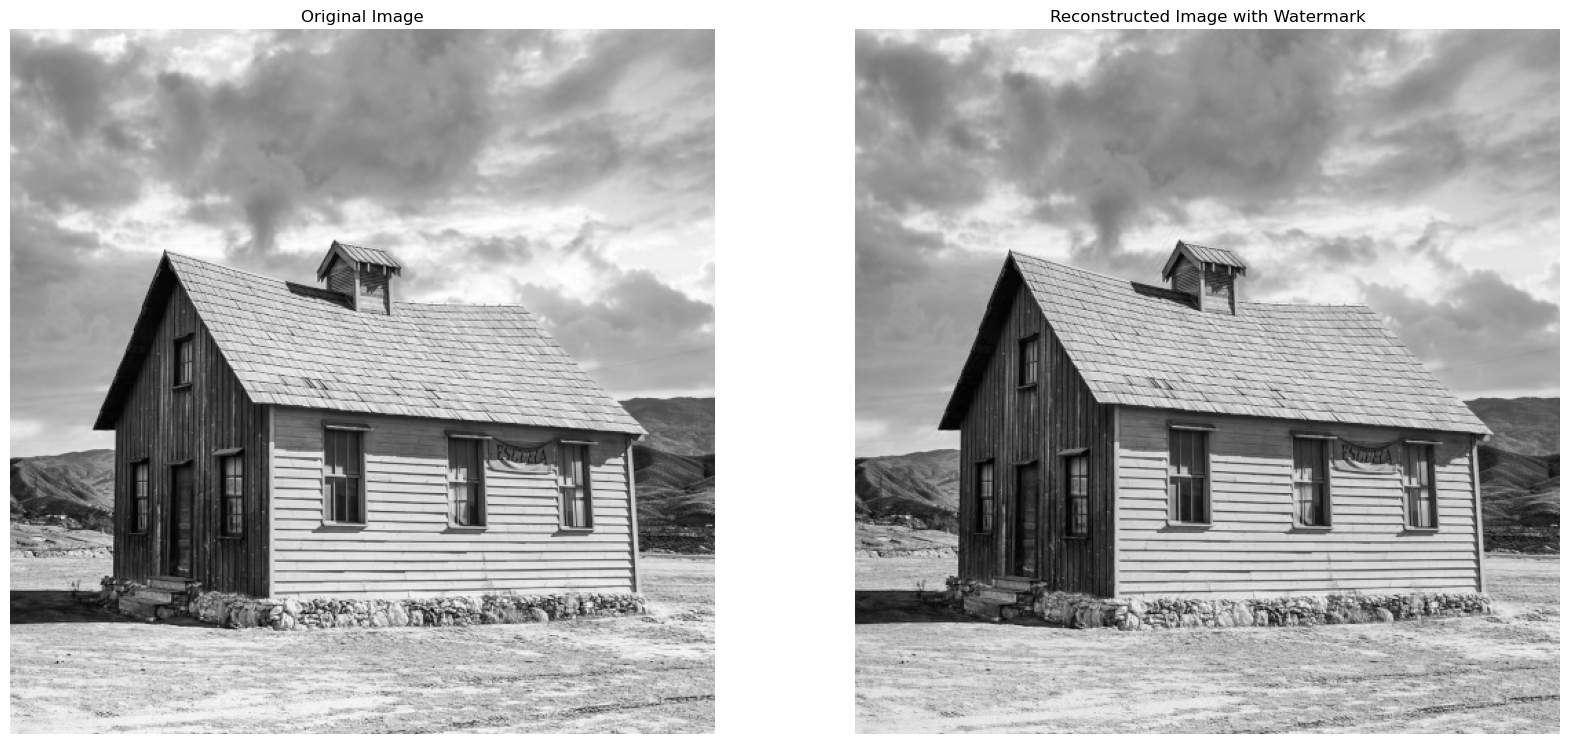

In [30]:
plt.figure(figsize=(20, 30))
plt.subplot(1, 2, 1).imshow(a_3_1, cmap='gray')
plt.subplot(1, 2, 1).axis('off')
plt.title("Original Image")
plt.subplot(1, 2, 2).imshow(np.abs(a_3_1_watermarked), cmap='gray')
plt.subplot(1, 2, 2).axis('off')
plt.title("Reconstructed Image with Watermark")

## f.

### Embedding the image at low frequencies would distort the image as low frequencies distort the image as low frequencies are visually dominant in an image.
### If we embed the image in high frequency, we won't see much change as very high frequencies correspond to fine details like edges and noise, so we won't observe much change in the image